## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Implementing Decision Tree Regression</p>

#### Decision Tree Regression is a supervised machine learning algorithm used to predict continuous values. It works by splitting the dataset into smaller groups based on feature values and making predictions using decision rules. Unlike Linear Regression, it can capture non-linear relationships between the features and the target variable.

### When to Use Decision Tree Regression

- When the relationship between features and the target is non-linear.
- When an interpretable model is needed.
- When working with numerical and categorical features.
- When feature scaling is not required.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

# Load the Dataset

In [2]:
df = pd.read_csv("../data/processed/auto_scout_final.csv")

df.shape

(15915, 140)

# Define Features and Target

In [3]:
# Separate the predictor variables and target variable.

X = df.drop("price", axis=1)
y = df["price"]

# Remove Rare Feature

In [4]:
# Remove the rare dummy variable if it exists.

if "make_model_Audi A2" in X.columns:
    X = X.drop(columns=["make_model_Audi A2"])

# Split the Dataset

In [5]:
# Split the dataset into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Split the Dataset

In [6]:
# Split the dataset into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create the Model

In [7]:
# Create the Decision Tree model.
# random_state ensures reproducible results.
# max_depth=None allows the tree to grow until stopping criteria are met.

tree = DecisionTreeRegressor(
    random_state=42,
    max_depth=None
)

# Train the Model

In [8]:
# Train the model using the training data.

tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

# Make Predictions

In [9]:
# Predict car prices for the test data.

y_pred = tree.predict(X_test)

# Evaluate the Model

In [10]:
# Calculate evaluation metrics.

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 1114.69
RMSE : 2197.80
R²   : 0.9105


 # Prediction Range

In [11]:
print("Minimum Prediction:", y_pred.min())
print("Maximum Prediction:", y_pred.max())

Minimum Prediction: 4990.0
Maximum Prediction: 74600.0


# Actual vs Predicted

In [12]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

results.head(10)

,Actual Price,Predicted Price
12887,26379,29200.0
8140,18990,18990.0
6835,12490,12950.0
15439,32975,31975.0
1213,15888,15750.0
13187,15480,15990.0
1034,20500,20500.0
2864,16760,17890.0
7061,18990,17850.0
14983,27000,24430.0


# Visualization

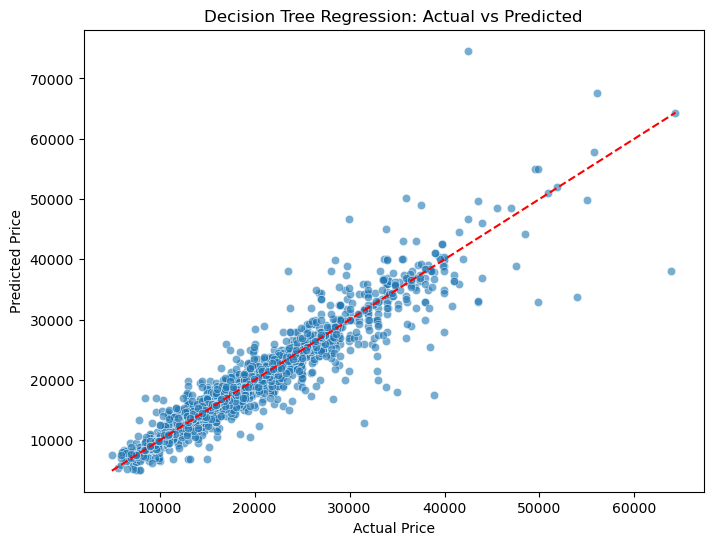

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree Regression: Actual vs Predicted")

plt.show()

# Feature Importance

In [14]:
# Display the most important features used by the Decision Tree.

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
2,hp,0.502892
13,year,0.198887
0,km,0.066181
21,make_model_Renault Espace,0.053443
11,gears,0.025844
9,weight,0.023403
47,gearing_type_Manual,0.012609
14,consumption_comb,0.012236
15,make_model_Audi A3,0.012116
16,make_model_Opel Astra,0.007277


## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Implementing Decision Tree Classifier</p>

Decision Tree Classifier is a supervised machine learning algorithm used for classification problems. It predicts a class label by splitting the data into smaller groups based on feature values. It is easy to interpret and can capture both linear and non-linear relationships.

### When to Use Decision Tree Classifier

- Binary or multi-class classification problems.
- Easy model interpretation.
- Numerical and categorical features.
- Non-linear relationships.

# Import Libraries

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Create Binary Target

In [16]:
# Convert price into Low Price (0) and High Price (1).

median_price = df["price"].median()

df["price_category"] = np.where(
    df["price"] >= median_price,
    1,
    0
)

df["price_category"].value_counts()

1    7986
0    7929
Name: price_category, dtype: int64

# Define Features and Target

In [17]:
X = df.drop(["price", "price_category"], axis=1)
y = df["price_category"]

# Remove Rare Feature
I did it at the beginning

# Split the Dataset - I ready did it

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create Model

In [19]:
# random_state ensures reproducible results.
# max_depth=None allows the tree to grow fully.

tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=None
)

# Train the model

In [20]:
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

# Make Predictions

In [21]:
y_pred = tree.predict(X_test)

# Evaluate Model

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

print("\nClassification Report")

#print(classification_report(y_test, y_pred))

Accuracy : 0.9485

Classification Report


# Confusion Matrix

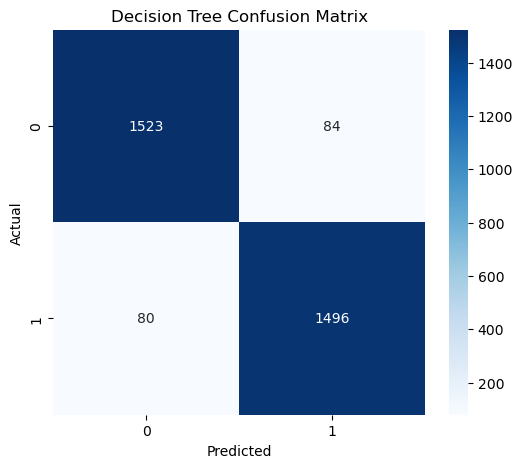

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

# Compare Predictions

In [24]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
12887,1,1
8140,1,0
6835,0,0
15439,1,1
1213,0,0
13187,0,0
1034,1,1
2864,0,0
7061,1,1
14983,1,1


##### The Decision Tree Classifier slightly outperformed the Logistic Regression model, achieving an accuracy of 94.85% compared to 94.72%. Although the improvement is small, it suggests that the Decision Tree was able to capture some non-linear patterns in the data that Logistic Regression could not. Both models demonstrated excellent classification performance.